# Using active spaces in `ci.overlap` and MOPAC workflow calculations

In this tutorial, we demonstrate how to reduce computational costs of time-overlap calculations by reducing the active space of orbitals included in the construction of SDs.


## Table of contents
<a name="toc"></a>

1. [Abstract example](#1)

   1.1. [Case 1](#1.1)
  
   1.2. [Case 2](#1.2)
  
   1.3. [Case 3](#1.3)
  
   1.4. [Case 4 - fool-proof mechanics](#1.4)
  
   1.5. [Case 5 - slightly-interacting orbitals](#1.5)  

2. [Using active spaces in the Libra/MOPAC workflow](#2)

   2.1. [Standard workflow](#2.1)
 
   2.2. [Truncated orbitals set - using orbital active space](#2.2)
 
   2.3. [Wrong truncation](#2.3)
 
   2.4. [A bit of convergence study](#2.4)
  
   2.5. [Comparison of the convergence](#2.5)  


### A. Learning objectives

* To extract the key infromation from the output file of MOPAC calculations (energies, MOs, CI vectors, etc.)
* To automate the calculations of the CI time-overlaps, adiabatic Hamiltonians, and adiabatic vibronic Hamiltonians using MOPAC
* To use the active space in MOPAC/Libra workflow to reduce computational expenses 


### B. Use cases

* INDO calculations with Libra 
* computing CI wavefunction time-overlaps with MOPAC
* define Libra/MOPAC interface Hamiltonian
* computing many-body (TD-DFT, TD-DFTB, CI) NACs

### C. Functions

- `libra_py`
  - `citools`
    - `ci`
      - [`overlap`](#overlap-1)
  - `packages`
    - `mopac`
      - `methods`
        - [`read_mopac_orbital_info`](#read_mopac_orbital_info-1)
        - [` mopac_compute_adi`](#mopac_compute_adi-1)
        

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import libra_py.packages.mopac.methods as mopac
import libra_py.packages.cp2k.methods as cp2k
import libra_py.units as units
import libra_py.citools.ci as ci

from liblibra_core import Py2Cpp_int

%matplotlib inline 

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 1. Abstract example
<a name="1"></a>
[Back to TOC](#toc)

This example is essentially included in the pytest files in `unittests/test_ci_overlaps_equivalence.py` but we'll explain the conventions used there.

### 1.1. Case 1
<a name="1.1"></a>
[Back to TOC](#toc)

Consider a simple case of two orbitals 1 and 2 that also span the active space.

As a result the MO time-overlap matrix should be a 2x2 matrix (`s`). Since all the functions are designed to work with the "doubled matrix" format that is composed of the alpha-alpha block (`s`) and beta-beta block (also `s`) on the diagonals and zeros on the off-diagonals (no spin-orbit coupling). The composed super-matrix is S.

We assume the the first orbital (1) is the only doubly-occupied orbital, hence:

- `homo_indx = 1`
- `nelec = 2` - one doubly-occupied orbital (1)
- `nocc = 0` - this is how many orbitals are occupied below HOMO. In this example, there are no such orbitals. 
   The lowst orbital in the active space will be `homo_indx - nocc = 1 - 0 = 1`
- `nvirt= 1` - how many orbitals are included above the HOMO. 1 means we also include LUMO (orbital 2)
   The highest orbital in the active space will be `homo_indx + nvirt = 1 + 1 = 2`

The span from the lowest orbital and the highest orbital shall be consistent with the size of the small matrix `s` and **should match its size** 

Notice that the coded single excited SD in this case `[1, 2]` corresponds to `1 (HOMO) -> 2 (LUMO)` excitation.
<a name="overlap-1"></a>

In [2]:
# ================= Case 1 ======================
print("Case 1")
s = np.array([
    [1.0, 0.2],
    [0.2, 1.2],
])
S = np.kron(np.eye(2), s)

# lowest = homo - nocc
# highest = homo + nvirt
params = dict(S=S, nelec=2, nocc=0, nvirt=1, homo_indx=1,nstates = 2,
        data = [ [],
                 [ [[1, 2]] ],
                 [ [1.0 ] ]
               ],
        active_space=None,
)

st_ci = ci.overlap(params["S"], params["data"], params["data"], params)

print("CI overlap:\n", st_ci)

Case 1
CI overlap:
 [[ 1.        +0.j -0.28284271+0.j]
 [-0.28284271+0.j  1.24      +0.j]]


### 1.2. Case 2
<a name="1.2"></a>
[Back to TOC](#toc)

Now, consider a situation when we have the same overplap of two orbitals, but shifted by 1 orbital up. 

So now we have set of orbitals 1, 2, and 3 with the orbital 2 being HOMO. We also set up the small matrix `s` such that the orbital 1 does not interact with orbitals 2 and 3 (the corresponding overlaps are all zeros)

As a result the MO time-overlap matrix should be a 3x3 matrix (`s`) and 

- `homo_indx = 2`
- `nelec = 4` - we now have two doubly-occupied orbital (1 and 2)
- `nocc = 1` - this is how many orbitals are occupied below HOMO. In this example, there is one such orbital (1). 
   The lowst orbital in the active space will be `homo_indx - nocc = 2 - 1 = 1`
- `nvirt= 1` - how many orbitals are included above the HOMO. 1 means we also include LUMO (orbital 3)
   The highest orbital in the active space will be `homo_indx + nvirt = 2 + 1 = 3`

The span from the lowest orbital and the highest orbital shall be consistent with the size of the small matrix `s` and **should match its size** 

Notice that the coded single excited SD in this case is different from the previous example and is given by `[2, 3]` corresponds to `2 (HOMO) -> 3 (LUMO)` excitation.

However, since the qualitative picture is the same as before, the CI overlap should state unchanged

In [3]:
# ================= Case 2 ======================
print("\nCase 2")
s = np.array([
    [-1.0, 0.0, 0.0],
    [0.0,  1.0, 0.2],
    [0.0,  0.2, 1.2],
])
S = np.kron(np.eye(2), s)

# lowest = homo - nocc
# highest = homo + nvirt
params = dict(S=S, nelec=4, nocc=1, nvirt=1, homo_indx=2, nstates = 2,
        data = [ [],
                 [ [[2, 3]] ],
                 [ [1.0 ] ]
               ],
        active_space=None,
)

st_ci = ci.overlap(params["S"], params["data"], params["data"], params)

print("CI overlap:\n", st_ci)


Case 2
CI overlap:
 [[ 1.        +0.j -0.28284271+0.j]
 [-0.28284271+0.j  1.24      +0.j]]


In both cases 1 and 2, we use `active_space = None` which means that all avaialbe orbitals will be used to create SD determinants (and hence could be pretty lengthy). In the first case, the SDs were of length 2 (two electrons). In the second case - they were of length 4 (4 electrons)

### 1.3. Case 3
<a name="1.3"></a>
[Back to TOC](#toc)

Now, we want to compute the case 2, but exclude HOMO-1 (orbital 1) from all calculations (and SD definitions). Howe to do this? 

In this case, all the parameters shall state the same as in case 2, except for two:

- `nelec = 2` - we now have only 1 doubly-occupied orbital (2)

- `active_space = [2, 3]` - it defines what orbitals will be considered. Since active space has only 1 doubly-occupied orbital (2), the number of electrons should be 2 

Notice that the excitations in the SD definition stays as before: `2 (HOMO) -> 3 (LUMO)`.

In [4]:
# ================= Case 3 ======================
print("\nCase 3")
s = np.array([
    [-1.0, 0.0, 0.0],
    [0.0,  1.0, 0.2],
    [0.0,  0.2, 1.2],
])
S = np.kron(np.eye(2), s)

# lowest = homo - nocc
# highest = homo + nvirt
params = dict(S=S, nelec=2, nocc=1, nvirt=1, homo_indx=2, nstates = 2,
        data = [ [],
                 [ [[2, 3]] ],
                 [ [1.0 ] ]
               ],
        active_space=[2, 3],
)

st_ci = ci.overlap(params["S"], params["data"], params["data"], params)

print("CI overlap:\n", st_ci)


Case 3
CI overlap:
 [[ 1.        +0.j -0.28284271+0.j]
 [-0.28284271+0.j  1.24      +0.j]]


### 1.4. Case 4 - fool-proof mechanics
<a name="1.4"></a>
[Back to TOC](#toc)

The `ci.overlap` function makes sure that the number of electrons is consistent with the active space used.

So, let's assume in the above example with the active space defined, we forgot to use reduce the number of electrons accordingly

In [5]:
# ================= Case 4 ======================
print("\nCase 4")
s = np.array([
    [-1.0, 0.0, 0.0],
    [0.0,  1.0, 0.2],
    [0.0,  0.2, 1.2],
])
S = np.kron(np.eye(2), s)

# lowest = homo - nocc
# highest = homo + nvirt
params = dict(S=S, nelec=4, nocc=1, nvirt=1, homo_indx=2, nstates = 2,
        data = [ [],
                 [ [[2, 3]] ],
                 [ [1.0 ] ]
               ],
        active_space=[2, 3],
)

st_ci = ci.overlap(params["S"], params["data"], params["data"], params)

print("CI overlap:\n", st_ci)


Case 4
CI overlap:
 [[ 1.        +0.j -0.28284271+0.j]
 [-0.28284271+0.j  1.24      +0.j]]


### 1.5. Case 5 - slightly-interacting orbitals
<a name="1.5"></a>
[Back to TOC](#toc)

In the examples above, the use of the active space was not a problem and was well-defined, since orbitals from the active space didn't "leak" into the inactive orbitals space (zero overlaps).

In [6]:
# ================= Case 5 ======================
print("\nCase 5")
s = np.array([
    [-1.0, 0.05, 0.02],
    [0.05,  1.0, 0.2],
    [0.02,  0.2, 1.2],
])
S = np.kron(np.eye(2), s)

# lowest = homo - nocc
# highest = homo + nvirt
params = dict(S=S, nelec=4, nocc=1, nvirt=1, homo_indx=2, nstates = 2,
        data = [ [],
                 [ [[2, 3]] ],
                 [ [1.0 ] ]
               ],
        active_space=None,
)

st_ci = ci.overlap(params["S"], params["data"], params["data"], params)
print("CI overlap without active space:\n", st_ci)

params.update({"nelec":2, "active_space":[2,3] })
st_ci = ci.overlap(params["S"], params["data"], params["data"], params)
print("CI overlap with active space:\n", st_ci)


Case 5
CI overlap without active space:
 [[ 1.00500625+0.j -0.28496757+0.j]
 [-0.28496757+0.j  1.243802  +0.j]]
CI overlap with active space:
 [[ 1.        +0.j -0.28284271+0.j]
 [-0.28284271+0.j  1.24      +0.j]]


## 2. Using active spaces in the Libra/MOPAC workflow
<a name="2"></a>
[Back to TOC](#toc)


### 2.1. Standard workflow
<a name="2.1"></a>
[Back to TOC](#toc)

We will be conducting the time-overlaps calculations for a realistic system without truncation first
`mopac_compute_adi` function.
<a name="mopac_compute_adi-1"></a>

In [7]:
%%time 
wd = "workflow_wd_standard"

labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", 0)
params_elem = {"labels":labels, "timestep":0, "is_first_time":True,
               "mopac_exe":"/home/alexvakimov/SOFTWARE/mopac/_build/mopac", 
               "mopac_run_params":"INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5",
               "mopac_working_directory":wd,
               "mopac_input_prefix":"tio2_", "mopac_output_prefix":"output_",
               "nstates":5,
               "dt":1.0*units.fs2au,
              }

# For 1 trajectory
params = [ dict(params_elem), ]

print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

# Do the first 5 steps 
for i in range(5):
    labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", i)
    params[0]["timestep"] = i
    
    obj = mopac.mopac_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{wd}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{wd}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{wd}/st_adi_{i}.txt")

[{'labels': ['Ti', 'O', 'O'], 'timestep': 0, 'is_first_time': True, 'mopac_exe': '/home/alexvakimov/SOFTWARE/mopac/_build/mopac', 'mopac_run_params': 'INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5', 'mopac_working_directory': 'workflow_wd_standard', 'mopac_input_prefix': 'tio2_', 'mopac_output_prefix': 'output_', 'nstates': 5, 'dt': 41.339396444811904}]


/home/alexvakimov/SOFTWARE/libra/_build/src/libra_py/packages/mopac/methods.py:637: ComplexWarning: Casting complex values to real discards the imaginary part
  obj.time_overlap_adi.set(istate, jstate, float(st_ci[istate, jstate]) * (1.0 + 0.0j))


CPU times: user 83.9 ms, sys: 7.61 ms, total: 91.5 ms
Wall time: 862 ms


Let' explore some of the dimensions from the output
<a name="read_mopac_orbital_info-1"></a>

In [8]:
filename = F"{wd}/tio2_timestep_0_traj_0.out"
read_params = {"nstates":5, "filename":filename, "orbital_space":None}
info, MO_curr, data_curr = mopac.read_mopac_orbital_info(read_params)

In [9]:
info

{'nocc': 8,
 'nelec': 16,
 'nao': 17,
 'nmo': 17,
 'nci': 5,
 'min_occ': 6,
 'max_occ': 8,
 'min_vir': 9,
 'max_vir': 11,
 'nact': 17,
 'actual_orbital_space': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17]}

This means:

- there are in total `nelec = 16` electrons
- they occupy `nocc = 8` doubly-occupied levels
- out of total `nao = nmo = 17` orbitals 
- so the untruncated active space is `[1, 2, ... 17]`
- this also means the `homo_indx = 8` (HOMO index)

Because in the INDO/CI we requested `CAS(6, 3)`, this means we have total of 6 levels around the HOMO index included in the CI active space (that is orbitals `6,7,8,9,10,11`), with  3 of them being the doubly occupied orbitals `6, 7, 8`. These numbers determine:
- `min_occ = 6` - the index of the lowest occupied orbital from the CI active space 
- `max_occ = 8` - the index of the highest occupied orbital from the CI active space (HOMO)
- `min_vir = 9` - the index of the lowest unoccupied orbital from the CI active space 
- `max_vir = 11` - the index of the highest unoccupied orbital from the CI active space 

In other words, the excitations would go as: `[6,7,8] -> [9, 10, 11]`

Note that these numbers are just the ones extracted from the output.

Inside of the `mopac_compute_adi` function the `ci.overlap` will be called with the parameters:

`nocc = info["nocc"] - 1 = 8 - 1 = 7`

and

`nvirt = info["nmo"] - info["nocc"] = 17 - 8 = 9`

This corresponds to using the whole space of 7 orbitals below HOMO, HOMO, and 9 orbitals above HOMO, so 17 in total - this is the dimension of the "small" MO matrix. 

Also, the calculations will use all 8 electrons to generate Slater determinans. 

### 2.2. Truncated orbitals set - using orbital active space
<a name="2.2"></a>
[Back to TOC](#toc)

We now conduct the same calculations but using the active space in the Libra/MOPAC workflow

All it takes to do is to define the active space of orbitals. For user convenience, the current approach is to define the active space internally - it includes all virtual orbitals and a number of occupied orbitals that is controlled by `nelec_act_space` keyword. Setting it to 2, for instance, will include only the HOMO orbital in the active space, 4 - will also add HOMO-1, and so on.

This number should be larger than `(nocc - min_occ + 1 )*2` 

For instance, for the above example of CAS(6,3), the number of electrons in determinants should be at least `(8 - 6 + 1)*2 = 6`. Otherwise, there will be not enough flexibility to create all possible SDs that can be encountered in the CI expansion.


In [10]:
%%time 
wd = "workflow_wd_truncated1"

labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", 0)
params_elem = {"labels":labels, "timestep":0, "is_first_time":True,
               "mopac_exe":"/home/alexvakimov/SOFTWARE/mopac/_build/mopac", 
               "mopac_run_params":"INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5",
               "mopac_working_directory":wd,
               "mopac_input_prefix":"tio2_", "mopac_output_prefix":"output_",
               "nstates":5,
               "dt":1.0*units.fs2au,
               "nelec_act_space":6
              }

# For 1 trajectory
params = [ dict(params_elem), ]

print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

# Do the first 5 steps 
for i in range(5):
    labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", i)
    params[0]["timestep"] = i
    
    obj = mopac.mopac_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{wd}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{wd}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{wd}/st_adi_{i}.txt")

[{'labels': ['Ti', 'O', 'O'], 'timestep': 0, 'is_first_time': True, 'mopac_exe': '/home/alexvakimov/SOFTWARE/mopac/_build/mopac', 'mopac_run_params': 'INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5', 'mopac_working_directory': 'workflow_wd_truncated1', 'mopac_input_prefix': 'tio2_', 'mopac_output_prefix': 'output_', 'nstates': 5, 'dt': 41.339396444811904, 'nelec_act_space': 6}]
CPU times: user 54.7 ms, sys: 13 ms, total: 67.6 ms
Wall time: 828 ms


### 2.3. Wrong truncation
<a name="2.3"></a>
[Back to TOC](#toc)

Here, we try to use only 2 electrons in the determinants - we get a correct error message

In [11]:
%%time 
wd = "workflow_wd_truncated_wrong"

labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", 0)
params_elem = {"labels":labels, "timestep":0, "is_first_time":True,
               "mopac_exe":"/home/alexvakimov/SOFTWARE/mopac/_build/mopac", 
               "mopac_run_params":"INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5",
               "mopac_working_directory":wd,
               "mopac_input_prefix":"tio2_", "mopac_output_prefix":"output_",
               "nstates":5,
               "dt":1.0*units.fs2au,
               "nelec_act_space":2
              }

# For 1 trajectory
params = [ dict(params_elem), ]

print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

# Do the first 5 steps 
for i in range(5):
    labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", i)
    params[0]["timestep"] = i
    
    obj = mopac.mopac_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{wd}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{wd}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{wd}/st_adi_{i}.txt")

[{'labels': ['Ti', 'O', 'O'], 'timestep': 0, 'is_first_time': True, 'mopac_exe': '/home/alexvakimov/SOFTWARE/mopac/_build/mopac', 'mopac_run_params': 'INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5', 'mopac_working_directory': 'workflow_wd_truncated_wrong', 'mopac_input_prefix': 'tio2_', 'mopac_output_prefix': 'output_', 'nstates': 5, 'dt': 41.339396444811904, 'nelec_act_space': 2}]


ValueError: The `nelec_act_space` should be at least 6

### 2.4. A bit of convergence study
<a name="2.4"></a>
[Back to TOC](#toc)

In [15]:
%%time 
wd = "workflow_wd_truncated2"

labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", 0)
params_elem = {"labels":labels, "timestep":0, "is_first_time":True,
               "mopac_exe":"/home/alexvakimov/SOFTWARE/mopac/_build/mopac", 
               "mopac_run_params":"INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5",
               "mopac_working_directory":wd,
               "mopac_input_prefix":"tio2_", "mopac_output_prefix":"output_",
               "nstates":5,
               "dt":1.0*units.fs2au,
               "nelec_act_space":10
              }

# For 1 trajectory
params = [ dict(params_elem), ]

print(params)

# Emulates 1 trajectory
full_id = Py2Cpp_int([0, 0])

# Do the first 5 steps 
for i in range(5):
    labels, q = cp2k.read_trajectory_xyz_file("TiO2-aligned.xyz", i)
    params[0]["timestep"] = i
    
    obj = mopac.mopac_compute_adi(q, params, full_id)        
    obj.ham_adi.show_matrix(F"{wd}/ham_adi_{i}.txt")
    obj.hvib_adi.show_matrix(F"{wd}/hvib_adi_{i}.txt")
    obj.time_overlap_adi.real().show_matrix(F"{wd}/st_adi_{i}.txt")

[{'labels': ['Ti', 'O', 'O'], 'timestep': 0, 'is_first_time': True, 'mopac_exe': '/home/alexvakimov/SOFTWARE/mopac/_build/mopac', 'mopac_run_params': 'INDO C.I.=(6,3) CHARGE=0 RELSCF=0.000001 ALLVEC  WRTCONF=0.00  WRTCI=5', 'mopac_working_directory': 'workflow_wd_truncated2', 'mopac_input_prefix': 'tio2_', 'mopac_output_prefix': 'output_', 'nstates': 5, 'dt': 41.339396444811904, 'nelec_act_space': 10}]
CPU times: user 58 ms, sys: 13.7 ms, total: 71.7 ms
Wall time: 902 ms


### 2.5. Comparison of the convergence
<a name="2.5"></a>
[Back to TOC](#toc)

In [16]:
X0, X1, X2 = [], [], []
for i in range(5):
    x0 = np.loadtxt(f"workflow_wd_standard/st_adi_{i}.txt")
    X0.append(x0)
    x1 = np.loadtxt(f"workflow_wd_truncated1/st_adi_{i}.txt")
    X1.append(x1)
    x2 = np.loadtxt(f"workflow_wd_truncated2/st_adi_{i}.txt")
    X2.append(x2)

X0 = np.array(X0)
X1 = np.array(X1)
X2 = np.array(X2)

print(X0.shape)

(5, 5, 5)


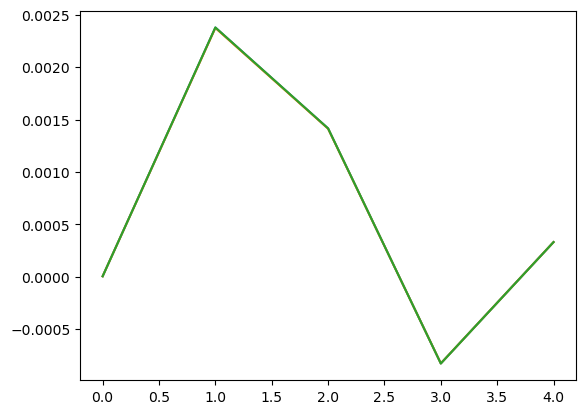

In [17]:
i,j = 1, 3 # couplings
#i,j = 1, 1 # self-overlaps 
plt.plot(X0[:, i, j], label="not truncated")
plt.plot(X1[:, i, j], label="6 electron-determinants")
plt.plot(X2[:, i, j], label="10 electron-determinants")
plt.show()